<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week4/Day3/Daily_challenge_W4_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#** Daily challenge:** Hands-On Image Transformation and Visualization




In [1]:
#Load and Visualize Images using the Flower Color Images dataset

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d olgabelitskaya/flower-color-images


!unzip flower-color-images.zip

Saving Flower Color Images dataset.zip to Flower Color Images dataset.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/olgabelitskaya/flower-color-images
License(s): other
100% 50.1M/50.1M [00:00<00:00, 86.9MB/s]

Archive:  flower-color-images.zip
  inflating: FlowerColorImages.h5    
  inflating: flower_images/flower_images/0001.png  
  inflating: flower_images/flower_images/0002.png  
  inflating: flower_images/flower_images/0003.png  
  inflating: flower_images/flower_images/0004.png  
  inflating: flower_images/flower_images/0005.png  
  inflating: flower_images/flower_images/0006.png  
  inflating: flower_images/flower_images/0007.png  
  inflating: flower_images/flower_images/0008.png  
  inflating: flower_images/flower_images/0009.png  
  inflating: flower_images/flower_images/0010.png  
  inflating: flower_images/flower_images/0011.png  
  inflati

In [2]:
#Install the libraries :
!pip install tensorflow
! pip install keras
! pip install pillow

In [16]:
import numpy as np
from  matplotlib import pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import random
import os
from PIL import Image

In [17]:
#Rotate an image by 90 degrees

from scipy.ndimage import rotate
def rotate_image_30_degrees(image):
    return rotate(image, angle=30, reshape=False)


In [5]:
#Flip an image horizontally and then vertically.
def flip_image(image):
    return np.flipud(np.fliplr(image))


In [18]:
#Zoom in on an image (scale by 1.2x) using .resize(...)
def zoom_in(image):
    return image.resize((int(image.size[0]*1.2), int(image.size[1]*1.2)))

Display the original and augmented images side by side for comparison using this function :


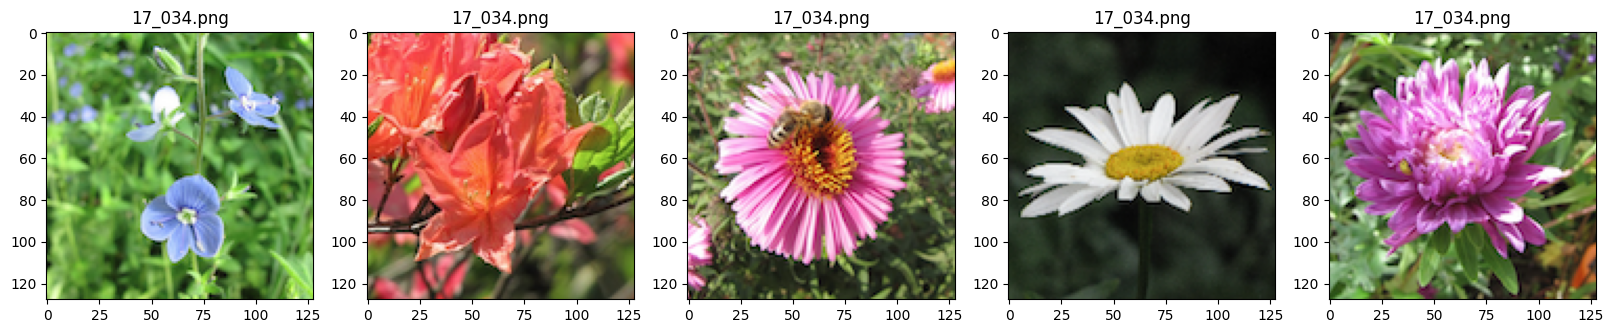

In [19]:
list_img = []
plt.figure(figsize=(20,20))
for i in range(5):
  file = random.choice(os.listdir('flowers/flowers'))
  image_path= os.path.join('flowers/flowers', file)
  img=mpimg.imread(image_path)
  list_img.append(img)

for i, img in enumerate(list_img):
  ax=plt.subplot(3,5,i+1)
  ax.title.set_text(file)
  plt.imshow(img)

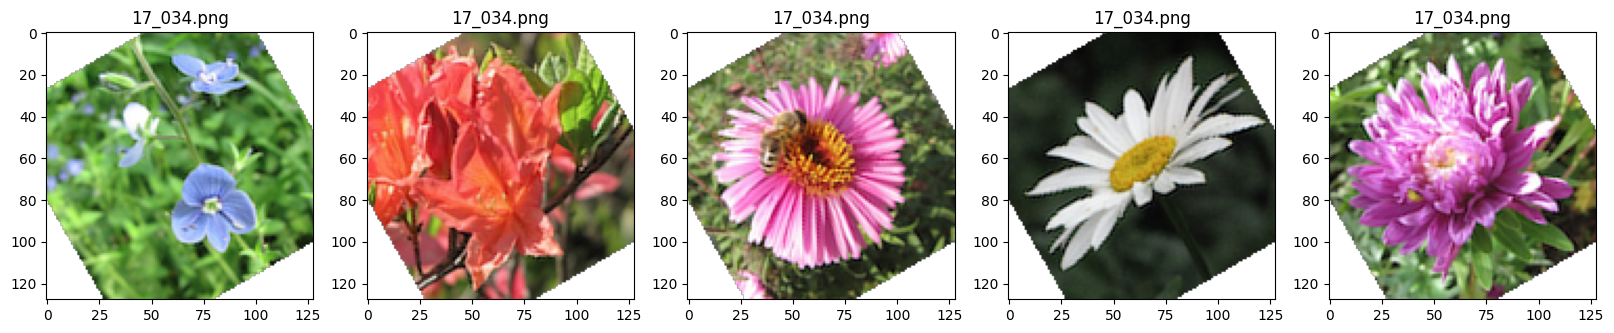

In [20]:
# To visualize the rotated images :
rotated_list = []
plt.figure(figsize=(20,20))
for img in list_img:
  rotated_list.append(rotate_image_30_degrees(img))

for i, img in enumerate(rotated_list):
    ax=plt.subplot(3,5,i+1)
    ax.title.set_text(file)
    plt.imshow(img)

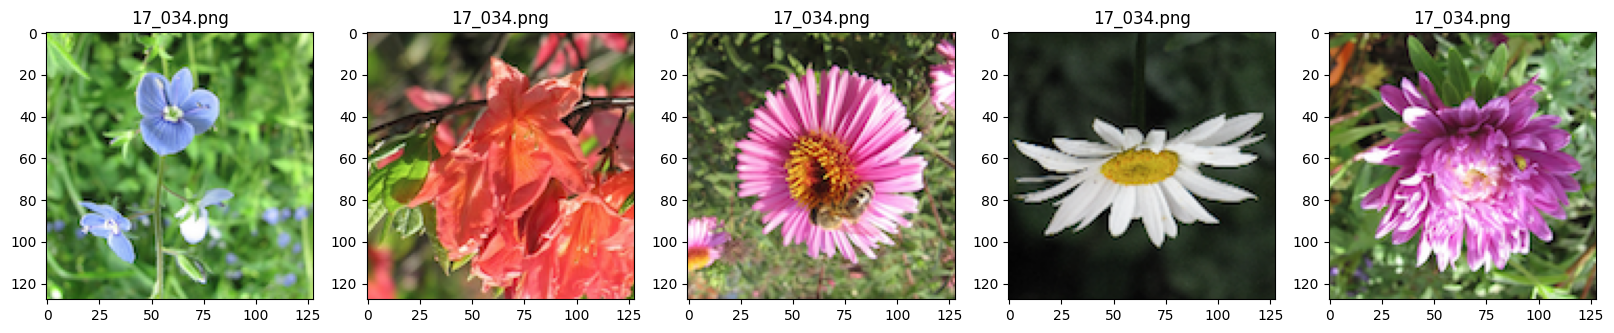

In [21]:
# To visualize the flip images :
flip_list = []
plt.figure(figsize=(20,20))
for img in list_img:
  flip_list.append(flip_image(img))

for i, img in enumerate(flip_list):
    ax=plt.subplot(3,5,i+1)
    ax.title.set_text(file)
    plt.imshow(img)

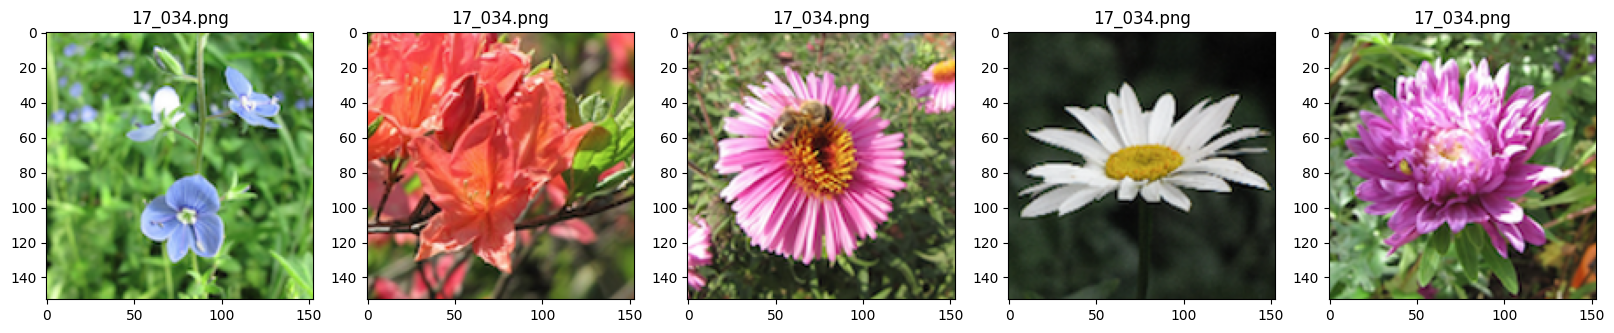

In [22]:
# To visualize the Zoom images :
zoom_list = []
plt.figure(figsize=(20,20))
for img_np in list_img:
  # Convert numpy array to PIL Image for the zoom_in function
  # mpimg.imread typically loads images as float32 in [0, 1]
  # PIL.Image.fromarray expects uint8 for RGB/RGBA images, so scale and convert type
  img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
  zoom_list.append(zoom_in(img_pil))

for i, img in enumerate(zoom_list):
    ax=plt.subplot(3,5,i+1)
    ax.title.set_text(file)
    plt.imshow(img)